# Gateway-Level Triage: Classification, Trust & Actionable Diagnostics

Builds on notebooks 22 (gateway decision analysis) and 23 (IG validation)
to produce a **decision-support system** for each process gateway:

1. **Gateway classification** — LSTM matches tree / Retrain LSTM / Keep LSTM
2. **Explanation trustworthiness** — Spearman IG-vs-surrogate correlation per gateway
3. **Error feature diagnostics** — Which features the LSTM overweights when wrong
4. **Disagreement extraction** — Specific prefixes for targeted retraining

## 1. Setup & Data Loading

In [1]:
import sys
from pathlib import Path
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))
print(f'Project root: {_current}')

Project root: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub


In [2]:
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from scipy.stats import spearmanr
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.interpretability.utils.tensor_decoder import TensorDecoder
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


In [ ]:
# --- Load dataset, model, decoder ---
data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat, n_num = len(sample[0]), len(sample[1])
seq_len = sample[0][0].shape[0]

from src.interpretability.config.helpdesk_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)
tool = InterpretabilityTool(model, model.data_set_categories, device=torch.device('cpu'))

ACT_IDX = 0
RES_IDX = 1
elapsed_num_idx = decoder.num_features.index('case_elapsed_time')
event_num_idx = decoder.num_features.index('event_elapsed_time')

cat_categories, num_categories = model.data_set_categories
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]
ALL_FEATURES = ALL_CAT_FEATURES + ALL_NUM_FEATURES

print(f'Dataset: {len(dataset)} sequences, seq_len={seq_len}')
print(f'Model features ({len(ALL_FEATURES)}): {ALL_FEATURES}')

## 2. Gateway Detection & Feature Extraction

In [4]:
MIN_CASES = 50
MIN_BRANCH = 10
MIN_SAMPLES_LEAF = 20
IG_STEPS = 30
MAX_IG_SAMPLES = 80  # cap IG per gateway

# --- Unique cases ---
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

# --- DFG ---
dfg = {}
for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    src_start = seq_len - trace_len
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]
    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break
    act_names = [activity_names[acts[j].item()] for j in range(useful_len)]
    for k in range(len(act_names) - 1):
        edge = (act_names[k], act_names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

successors_map = {}
for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {
    act: succs for act, succs in successors_map.items()
    if len(succs) > 1
}

print(f'{len(cases)} cases, {len(decision_points)} decision points')
for act, succs in sorted(decision_points.items(), key=lambda x: -sum(x[1].values())):
    total = sum(succs.values())
    branches = ', '.join(f'{s} ({c})' for s, c in sorted(succs.items(), key=lambda x: -x[1]))
    print(f'  {act} ({total}): {branches}')

916 cases, 9 decision points
  Take in charge ticket (996): Resolve ticket (717), Wait (243), Take in charge ticket (16), Require upgrade (12), Create SW anomaly (7), Schedule intervention (1)
  Assign seriousness (995): Take in charge ticket (837), Assign seriousness (96), Resolve ticket (50), Wait (11), Require upgrade (1)
  Resolve ticket (987): Closed (910), Resolve ticket (50), Take in charge ticket (26), RESOLVED (1)
  Wait (279): Resolve ticket (153), Take in charge ticket (99), Wait (24), Require upgrade (1), Create SW anomaly (1), Assign seriousness (1)
  Insert ticket (28): Assign seriousness (26), Wait (2)
  Require upgrade (20): Resolve ticket (9), Require upgrade (4), Wait (3), Create SW anomaly (3), Take in charge ticket (1)
  Create SW anomaly (12): Resolve ticket (8), Require upgrade (2), Create SW anomaly (1), Resolve SW anomaly (1)
  Closed (6): Closed (5), Take in charge ticket (1)
  Resolve SW anomaly (2): Resolve SW anomaly (1), Require upgrade (1)


In [5]:
def extract_features(cat_tuple, num_tuple, decoder):
    act_tensor = cat_tuple[ACT_IDX]
    mask = act_tensor != 0
    prefix_len = int(mask.sum().item())
    if prefix_len == 0:
        return None
    nonzero = mask.nonzero(as_tuple=True)[0]
    start = nonzero[0].item()
    end = start + prefix_len
    acts = act_tensor[start:end]

    last_act = acts[-1].item()
    repeated = 1
    for k in range(len(acts) - 2, -1, -1):
        if acts[k].item() == last_act:
            repeated += 1
        else:
            break

    total_elapsed = decoder.decode_numerical_value('case_elapsed_time', num_tuple[elapsed_num_idx][end - 1].item())
    last_event_dur = decoder.decode_numerical_value('event_elapsed_time', num_tuple[event_num_idx][end - 1].item())
    event_durs = [decoder.decode_numerical_value('event_elapsed_time', num_tuple[event_num_idx][j].item()) for j in range(start, end)]

    res_tensor = cat_tuple[RES_IDX]
    resources = res_tensor[start:end].tolist()

    feats = {
        'prefix_length': prefix_len,
        'first_activity': decoder.decode_categorical_value(ACT_IDX, acts[0].item()),
        'n_unique_activities': len(set(acts.tolist())),
        'last_activity_repeated': repeated,
        'total_elapsed_time': total_elapsed,
        'last_event_duration': last_event_dur,
        'mean_event_duration': float(np.mean(event_durs)),
        'last_resource': decoder.decode_categorical_value(RES_IDX, res_tensor[end - 1].item()),
        'n_unique_resources': len(set(resources)),
        'resource_changed': int(len(set(resources)) > 1),
    }
    for ci, feat_name in enumerate(decoder.cat_features):
        if ci == ACT_IDX:
            continue
        feats[f'last_{feat_name}'] = str(decoder.decode_categorical_value(ci, cat_tuple[ci][end - 1].item()))
    for ni, feat_name in enumerate(decoder.num_features):
        feats[f'last_{feat_name}'] = decoder.decode_numerical_value(feat_name, num_tuple[ni][end - 1].item())
    return feats


# --- Collect per-gateway data ---
gateway_data = {}

for gateway_act, succs in decision_points.items():
    qualifying_branches = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying_branches) < 2 or sum(succs.values()) < MIN_CASES:
        continue

    feature_rows, actual_labels = [], []
    cat_list, num_list, prefix_len_list = [], [], []

    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        src_start = seq_len - trace_len
        acts = cat_full[ACT_IDX][src_start:src_start + trace_len]
        useful_len = trace_len
        for j in range(trace_len - 1, -1, -1):
            if acts[j].item() == eos_idx: useful_len = j
            else: break

        for k in range(useful_len - 1):
            if activity_names[acts[k].item()] != gateway_act:
                continue
            next_act_name = activity_names[acts[k + 1].item()]
            plen = k + 1
            pad_len = seq_len - plen
            cat_prefix = []
            for c in cat_full:
                t = torch.zeros_like(c)
                t[pad_len:] = c[src_start:src_start + plen]
                cat_prefix.append(t)
            num_prefix = []
            for n in num_full:
                t = torch.zeros_like(n)
                t[pad_len:] = n[src_start:src_start + plen]
                num_prefix.append(t)

            feats = extract_features(tuple(cat_prefix), tuple(num_prefix), decoder)
            if feats is not None:
                feature_rows.append(feats)
                actual_labels.append(next_act_name)
                cat_list.append(cat_prefix)
                num_list.append(num_prefix)
                prefix_len_list.append(plen)

    if len(feature_rows) < MIN_CASES:
        continue

    X = pd.DataFrame(feature_rows)
    y_actual = np.array(actual_labels)

    N = len(X)
    cat_batch = [torch.stack([cat_list[i][ci] for i in range(N)]) for ci in range(n_cat)]
    num_stacked = torch.stack([torch.stack(num_list[i], dim=-1) for i in range(N)])
    preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
    y_lstm = np.array([activity_names[p] for p in preds])

    gateway_data[gateway_act] = {
        'X': X, 'y_lstm': y_lstm, 'y_actual': y_actual,
        'successors': succs, 'probs': probs,
        'cat_list': cat_list, 'num_list': num_list,
        'prefix_len_list': prefix_len_list,
    }
    lstm_acc = (y_lstm == y_actual).mean()
    print(f'{gateway_act}: {N} prefixes, LSTM acc={lstm_acc:.3f}')

print(f'\n{len(gateway_data)} qualifying gateways')

Assign seriousness: 995 prefixes, LSTM acc=0.412
Take in charge ticket: 996 prefixes, LSTM acc=0.672
Resolve ticket: 987 prefixes, LSTM acc=0.939
Wait: 279 prefixes, LSTM acc=0.556

4 qualifying gateways


## 3. Train Surrogate & Ground-Truth Trees

In [6]:
def select_best_depth(X_train, y_train, X_test, y_test, depths=(3, 4, 5, 6, 8, None)):
    results = []
    for depth in depths:
        clf = DecisionTreeClassifier(
            max_depth=depth, min_samples_leaf=MIN_SAMPLES_LEAF,
            class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train)
        results.append({'depth': depth, 'test': clf.score(X_test, y_test), 'clf': clf})
    best_idx = 0
    best_test = results[0]['test']
    for i in range(1, len(results)):
        if results[i]['test'] > best_test + 0.02:
            best_idx = i
            best_test = results[i]['test']
    return results[best_idx]['clf']


gateway_results = {}

for gateway_act, gd in gateway_data.items():
    X, y_lstm, y_actual = gd['X'], gd['y_lstm'], gd['y_actual']

    cat_cols = [c for c in X.columns if X[c].dtype == 'object']
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_enc = X.copy()
    X_enc[cat_cols] = ord_enc.fit_transform(X[cat_cols].astype(str))

    cat_mappings = {}
    for i, col in enumerate(cat_cols):
        cat_mappings[col] = list(ord_enc.categories_[i])

    try:
        X_train, X_test, y_lstm_train, y_lstm_test, y_actual_train, y_actual_test = \
            train_test_split(X_enc, y_lstm, y_actual, test_size=0.2, random_state=42, stratify=y_actual)
    except ValueError:
        X_train, X_test, y_lstm_train, y_lstm_test, y_actual_train, y_actual_test = \
            train_test_split(X_enc, y_lstm, y_actual, test_size=0.2, random_state=42)

    clf_lstm = select_best_depth(X_train, y_lstm_train, X_test, y_lstm_test)
    clf_gt = select_best_depth(X_train, y_actual_train, X_test, y_actual_test)

    surr_fidelity = clf_lstm.score(X_test, y_lstm_test)
    gt_accuracy = clf_gt.score(X_test, y_actual_test)
    lstm_accuracy = (y_lstm_test == y_actual_test).mean()

    gateway_results[gateway_act] = {
        'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
        'feature_names': list(X_enc.columns),
        'cat_cols': cat_cols, 'cat_mappings': cat_mappings,
        'ord_enc': ord_enc,
        'X_train': X_train, 'X_test': X_test,
        'y_lstm_train': y_lstm_train, 'y_lstm_test': y_lstm_test,
        'y_actual_train': y_actual_train, 'y_actual_test': y_actual_test,
        'surrogate_fidelity': surr_fidelity,
        'gt_accuracy': gt_accuracy,
        'lstm_accuracy': lstm_accuracy,
        'n_cases': len(X),
    }
    print(f'{gateway_act}: LSTM acc={lstm_accuracy:.3f}, Fidelity={surr_fidelity:.3f}, GT acc={gt_accuracy:.3f}')

Assign seriousness: LSTM acc=0.432, Fidelity=0.859, GT acc=0.789
Take in charge ticket: LSTM acc=0.665, Fidelity=0.965, GT acc=0.665
Resolve ticket: LSTM acc=0.924, Fidelity=0.864, GT acc=0.818
Wait: LSTM acc=0.554, Fidelity=0.554, GT acc=0.482


## 4. Gateway Classification & Triage Table

In [7]:
FIDELITY_THRESH = 0.70
LSTM_ACC_HIGH = 0.70
GT_ACC_HIGH = 0.70

def classify_gateway(lstm_acc, surr_fidelity, gt_acc):
    """Classify gateway into actionable category."""
    high_fidelity = surr_fidelity >= FIDELITY_THRESH

    if high_fidelity and lstm_acc >= LSTM_ACC_HIGH and gt_acc >= GT_ACC_HIGH:
        return 'LSTM_MATCHES_TREE'
    elif high_fidelity and lstm_acc < LSTM_ACC_HIGH:
        return 'RETRAIN_LSTM'
    elif high_fidelity and lstm_acc >= LSTM_ACC_HIGH and gt_acc < GT_ACC_HIGH:
        return 'KEEP_LSTM'
    elif not high_fidelity and lstm_acc >= LSTM_ACC_HIGH:
        return 'KEEP_LSTM'
    elif not high_fidelity and lstm_acc < LSTM_ACC_HIGH:
        return 'RETRAIN_LSTM'
    else:
        return 'INVESTIGATE'


triage_rows = []
for gw, gr in gateway_results.items():
    category = classify_gateway(gr['lstm_accuracy'], gr['surrogate_fidelity'], gr['gt_accuracy'])
    triage_rows.append({
        'Gateway': gw,
        'Cases': gr['n_cases'],
        'LSTM Acc': gr['lstm_accuracy'],
        'Fidelity': gr['surrogate_fidelity'],
        'GT Tree Acc': gr['gt_accuracy'],
        'Category': category,
    })

triage_df = pd.DataFrame(triage_rows)

# Color-coded display
def style_triage(row):
    cat = row['Category']
    colors = {
        'LSTM_MATCHES_TREE': 'background-color: #d4edda; color: black',  # green
        'RETRAIN_LSTM': 'background-color: #f8d7da; color: black',       # red
        'KEEP_LSTM': 'background-color: #cce5ff; color: black',          # blue
        'INVESTIGATE': 'background-color: #fff3cd; color: black',         # yellow
    }
    return [colors.get(cat, '')] * len(row)

print("Gateway Classification Triage")
print("=" * 80)
print(f"  LSTM_MATCHES_TREE: High fidelity + High LSTM acc + High GT acc (tree-replaceable)")
print(f"  RETRAIN_LSTM:      High fidelity + Low LSTM acc (tree captures the failure)")
print(f"  KEEP_LSTM:         LSTM outperforms tree, or tree can't capture LSTM behavior")
print(f"  Thresholds: fidelity >= {FIDELITY_THRESH}, acc >= {LSTM_ACC_HIGH}")
print("=" * 80)
display(triage_df.style.apply(style_triage, axis=1).format({
    'LSTM Acc': '{:.3f}', 'Fidelity': '{:.3f}', 'GT Tree Acc': '{:.3f}'}))

# Summary counts
print("\nTriage summary:")
for cat in ['LSTM_MATCHES_TREE', 'RETRAIN_LSTM', 'KEEP_LSTM', 'INVESTIGATE']:
    count = (triage_df['Category'] == cat).sum()
    if count > 0:
        gateways = triage_df[triage_df['Category'] == cat]['Gateway'].tolist()
        print(f"  {cat}: {count} — {', '.join(gateways)}")

Gateway Classification Triage
  LSTM_MATCHES_TREE: High fidelity + High LSTM acc + High GT acc (tree-replaceable)
  RETRAIN_LSTM:      High fidelity + Low LSTM acc (tree captures the failure)
  KEEP_LSTM:         LSTM outperforms tree, or tree can't capture LSTM behavior
  Thresholds: fidelity >= 0.7, acc >= 0.7


,Gateway,Cases,LSTM Acc,Fidelity,GT Tree Acc,Category
0,Assign seriousness,995,0.432,0.859,0.789,RETRAIN_LSTM
1,Take in charge ticket,996,0.665,0.965,0.665,RETRAIN_LSTM
2,Resolve ticket,987,0.924,0.864,0.818,LSTM_MATCHES_TREE
3,Wait,279,0.554,0.554,0.482,RETRAIN_LSTM



Triage summary:
  LSTM_MATCHES_TREE: 1 — Resolve ticket
  RETRAIN_LSTM: 3 — Assign seriousness, Take in charge ticket, Wait


## 5. IG Attribution per Gateway (Trust & Error Diagnostics)

In [8]:
ig_results = {}

for gateway_act, gd in gateway_data.items():
    N = len(gd['X'])
    rng = np.random.RandomState(42)
    sample_indices = rng.choice(N, min(MAX_IG_SAMPLES, N), replace=False).tolist() if N > MAX_IG_SAMPLES else list(range(N))

    print(f'{gateway_act}: computing IG for {len(sample_indices)}/{N} prefixes...')
    rows = []

    for idx in tqdm(sample_indices, desc=gateway_act):
        cat_tensors = [c.clone() for c in gd['cat_list'][idx]]
        num_tensors = [n.clone() for n in gd['num_list'][idx]]
        prefix_len = gd['prefix_len_list'][idx]

        try:
            attr_map = tool.compute_attribution_map(
                process=(cat_tensors, num_tensors),
                prefix_length=prefix_len,
                target=ACTIVITY_FEATURE,
                target_class='auto',
                method='integrated_gradients',
                n_steps=IG_STEPS,
            )
            feature_attrs = {}
            for feat in ALL_FEATURES:
                if feat in attr_map.attributions:
                    vals = attr_map.attributions[feat]
                    if hasattr(vals, 'detach'):
                        vals = vals.detach().cpu().numpy()
                    feature_attrs[feat] = float(np.abs(vals).sum())

            feature_attrs['y_lstm'] = gd['y_lstm'][idx]
            feature_attrs['y_actual'] = gd['y_actual'][idx]
            feature_attrs['is_correct'] = gd['y_lstm'][idx] == gd['y_actual'][idx]
            rows.append(feature_attrs)
        except Exception as e:
            print(f'  Error idx {idx}: {e}')

    if rows:
        ig_results[gateway_act] = pd.DataFrame(rows)
        print(f'  {len(rows)} attributions computed')

print(f'\nIG results for {len(ig_results)} gateways')

Assign seriousness: computing IG for 80/995 prefixes...


Assign seriousness:   0%|          | 0/80 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 6. Explanation Trustworthiness (Spearman IG vs Surrogate)

In [ ]:
def map_ig_to_surrogate(feat, surr_imp):
    """Map model-level feature to best-matching surrogate engineered feature."""
    direct = surr_imp.get(f'last_{feat}', surr_imp.get(feat, 0.0))
    related = {
        'Resource': ['last_resource', 'n_unique_resources', 'resource_changed'],
        'case_elapsed_time': ['total_elapsed_time'],
        'event_elapsed_time': ['last_event_duration', 'mean_event_duration'],
        'Activity': ['first_activity', 'n_unique_activities', 'last_activity_repeated'],
    }
    vals = [direct] + [surr_imp.get(k, 0.0) for k in related.get(feat, [])]
    return max(vals)


trust_rows = []
for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    gr = gateway_results[gateway_act]
    ig_features = [f for f in ALL_FEATURES if f in ig_df.columns]
    ig_mean = ig_df[ig_features].mean()

    surr_imp = dict(zip(gr['feature_names'], gr['clf_lstm'].feature_importances_))
    gt_imp = dict(zip(gr['feature_names'], gr['clf_gt'].feature_importances_))

    ig_ranks, surr_ranks = [], []
    for feat in ig_features:
        ig_ranks.append(ig_mean[feat])
        surr_ranks.append(map_ig_to_surrogate(feat, surr_imp))

    rho, p_val = spearmanr(ig_ranks, surr_ranks)

    trust_rows.append({
        'Gateway': gateway_act,
        'Spearman_r': rho,
        'p_value': p_val,
        'Trustworthy': 'Yes' if (rho > 0.4 and p_val < 0.1) else 'No',
        'Category': triage_df[triage_df['Gateway'] == gateway_act]['Category'].iloc[0],
    })

trust_df = pd.DataFrame(trust_rows)
print("Explanation Trustworthiness (IG vs Surrogate Feature Ranking)")
print("=" * 80)
print("High Spearman r => tree explanation uses same features as the LSTM")
print("Low Spearman r  => tree gets right answer for wrong reasons")
print("=" * 80)
display(trust_df.style.format({'Spearman_r': '{:.3f}', 'p_value': '{:.3f}'}))

Explanation Trustworthiness (IG vs Surrogate Feature Ranking)
High Spearman r => tree explanation uses same features as the LSTM
Low Spearman r  => tree gets right answer for wrong reasons


,Gateway,Spearman_r,p_value,Trustworthy,Category
0,Assign seriousness,0.476,0.063,Yes,RETRAIN_LSTM
1,Take in charge ticket,0.257,0.336,No,RETRAIN_LSTM
2,Resolve ticket,0.253,0.344,No,LSTM_MATCHES_TREE
3,Wait,0.228,0.396,No,RETRAIN_LSTM


## 7. Error Feature Diagnostics (Overweighted Features When Wrong)

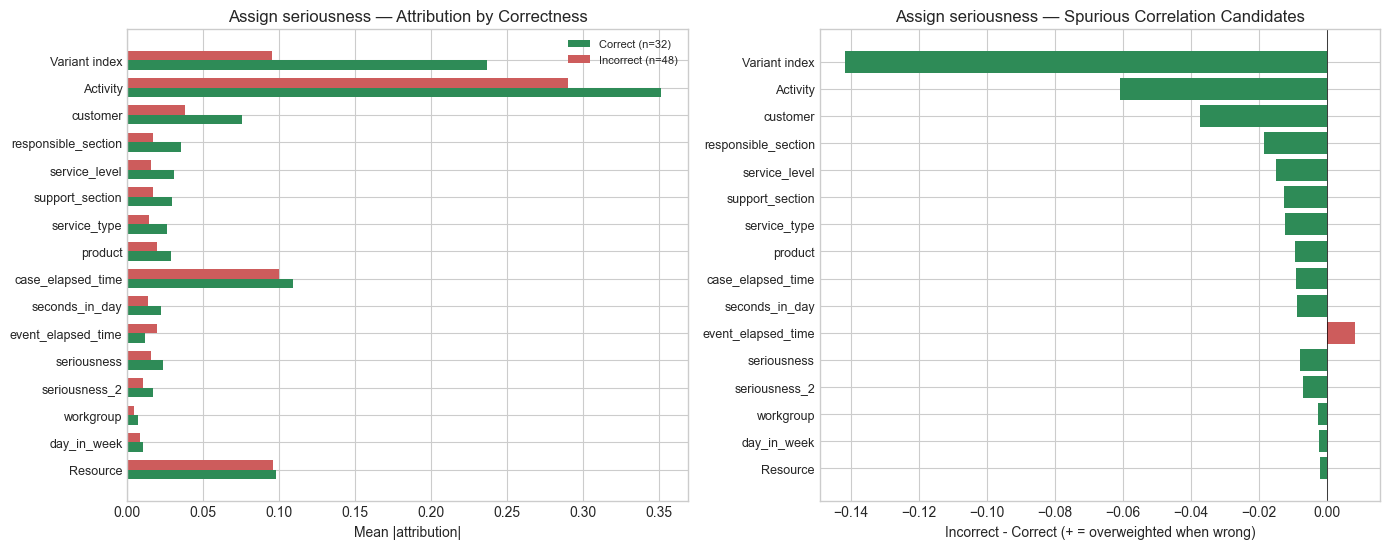

  Assign seriousness — Spurious correlation hypotheses:
    event_elapsed_time: +0.0082 more attribution when wrong (rel: +71.8%) -> possible spurious signal


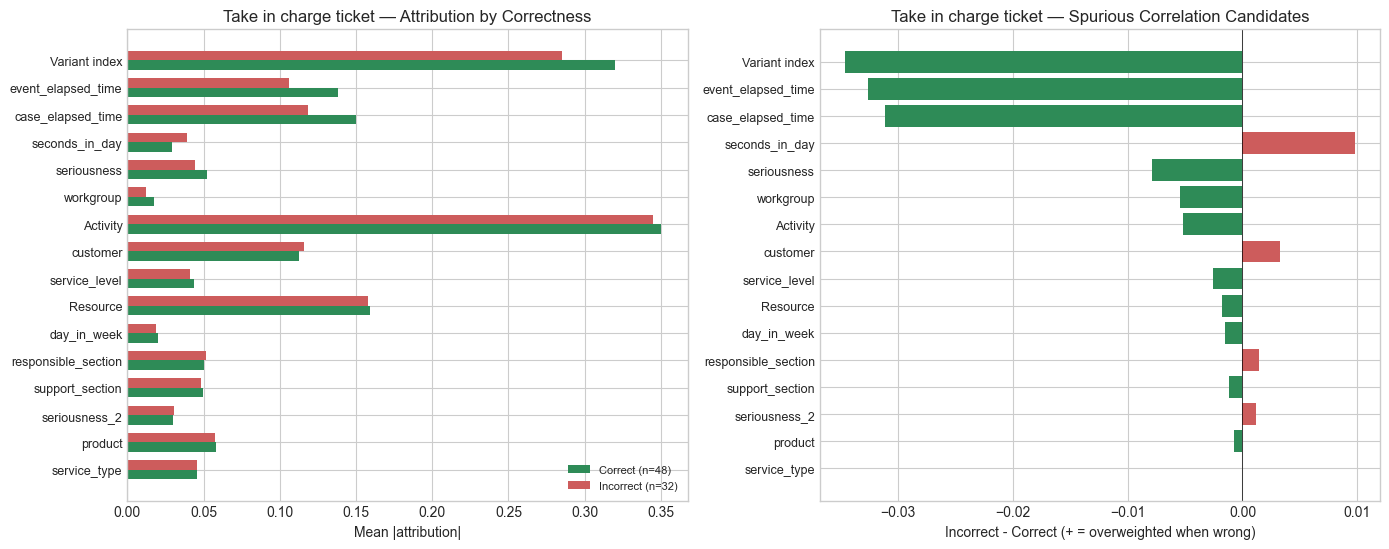

  Take in charge ticket — Spurious correlation hypotheses:
    seconds_in_day: +0.0098 more attribution when wrong (rel: +33.4%) -> possible spurious signal
    customer: +0.0033 more attribution when wrong (rel: +2.9%) -> possible spurious signal
    responsible_section: +0.0014 more attribution when wrong (rel: +2.8%) -> possible spurious signal


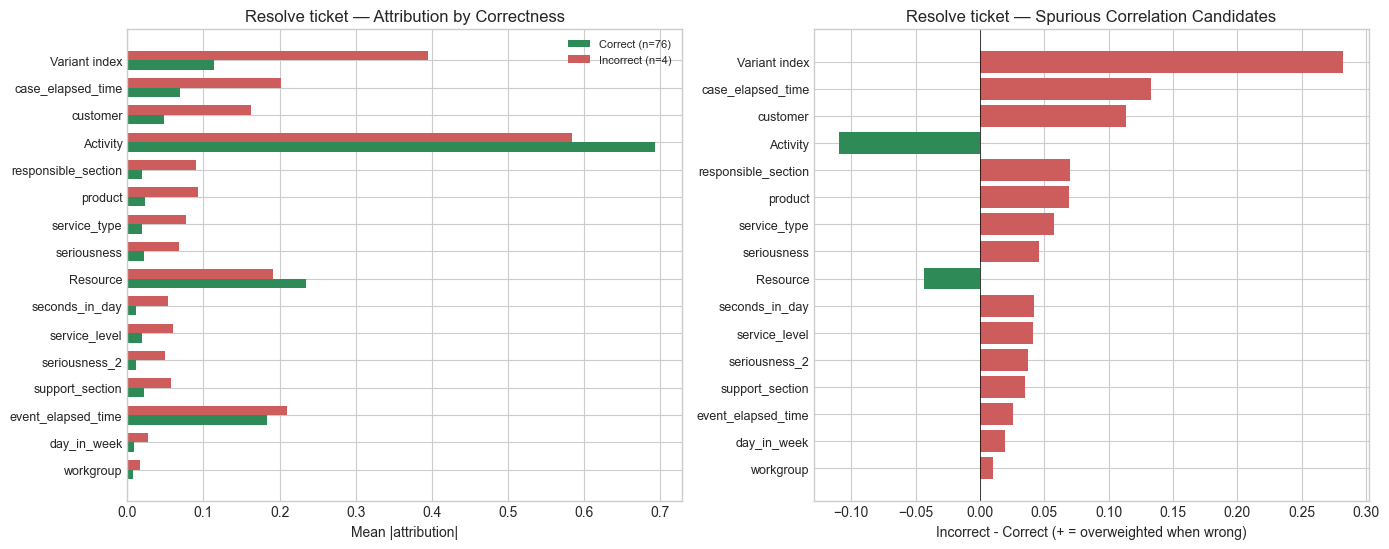

  Resolve ticket — Spurious correlation hypotheses:
    Variant index: +0.2824 more attribution when wrong (rel: +249.5%) -> possible spurious signal
    case_elapsed_time: +0.1331 more attribution when wrong (rel: +192.2%) -> possible spurious signal
    customer: +0.1133 more attribution when wrong (rel: +233.4%) -> possible spurious signal


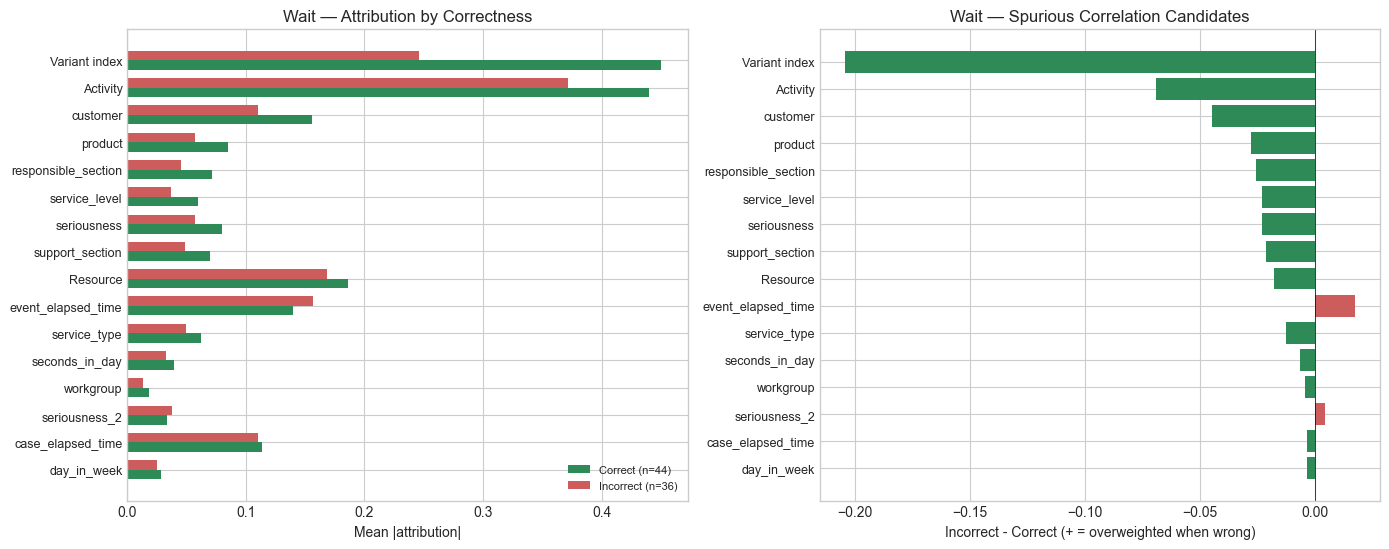

  Wait — Spurious correlation hypotheses:
    event_elapsed_time: +0.0171 more attribution when wrong (rel: +12.3%) -> possible spurious signal
    seriousness_2: +0.0041 more attribution when wrong (rel: +12.4%) -> possible spurious signal


In [ ]:
error_diagnostics = {}

for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    ig_features = [f for f in ALL_FEATURES if f in ig_df.columns]

    correct = ig_df[ig_df['is_correct'] == True]
    incorrect = ig_df[ig_df['is_correct'] == False]

    if len(incorrect) < 3:
        print(f'{gateway_act}: only {len(incorrect)} errors — skipping diagnostics')
        continue

    mean_correct = correct[ig_features].mean()
    mean_incorrect = incorrect[ig_features].mean()
    diff = mean_incorrect - mean_correct

    # Normalize by correct mean to get relative overweighting
    rel_diff = diff / (mean_correct + 1e-8)

    error_diagnostics[gateway_act] = {
        'mean_correct': mean_correct,
        'mean_incorrect': mean_incorrect,
        'diff': diff,
        'rel_diff': rel_diff,
        'n_correct': len(correct),
        'n_incorrect': len(incorrect),
    }

    # Visualization
    order = diff.abs().sort_values(ascending=True).index  # ascending for horizontal bars
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(ig_features) * 0.35)))

    y_pos = np.arange(len(order))
    bar_h = 0.35
    ax = axes[0]
    ax.barh(y_pos - bar_h/2, mean_correct[order].values, bar_h,
            label=f'Correct (n={len(correct)})', color='seagreen')
    ax.barh(y_pos + bar_h/2, mean_incorrect[order].values, bar_h,
            label=f'Incorrect (n={len(incorrect)})', color='indianred')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel('Mean |attribution|')
    ax.set_title(f'{gateway_act} — Attribution by Correctness')
    ax.legend(fontsize=8)

    ax = axes[1]
    colors = ['indianred' if d > 0 else 'seagreen' for d in diff[order].values]
    ax.barh(y_pos, diff[order].values, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Incorrect - Correct (+ = overweighted when wrong)')
    ax.set_title(f'{gateway_act} — Spurious Correlation Candidates')
    plt.tight_layout()
    plt.show()

    # Print hypothesis
    overweighted = diff[diff > 0].sort_values(ascending=False).head(3)
    if len(overweighted) > 0:
        print(f'  {gateway_act} — Spurious correlation hypotheses:')
        for feat, val in overweighted.items():
            print(f'    {feat}: +{val:.4f} more attribution when wrong '
                  f'(rel: {rel_diff[feat]:+.1%}) -> possible spurious signal')

## 8. Disagreement Extraction (Targeted Retraining Candidates)

In [ ]:
retraining_candidates = {}

for gateway_act, gr in gateway_results.items():
    y_surr = gr['clf_lstm'].predict(gr['X_test'])
    y_gt_pred = gr['clf_gt'].predict(gr['X_test'])

    # Cases where surrogate and GT tree disagree
    disagree_mask = y_surr != y_gt_pred
    n_disagree = disagree_mask.sum()
    n_total = len(gr['X_test'])

    if n_disagree == 0:
        continue

    # Among disagreements: what's the LSTM doing?
    lstm_wrong_mask = gr['y_lstm_test'] != gr['y_actual_test']
    disagree_and_wrong = disagree_mask & lstm_wrong_mask

    disagree_df = gr['X_test'][disagree_mask].copy()
    disagree_df['surrogate_pred'] = y_surr[disagree_mask]
    disagree_df['gt_pred'] = y_gt_pred[disagree_mask]
    disagree_df['lstm_pred'] = gr['y_lstm_test'][disagree_mask]
    disagree_df['actual'] = gr['y_actual_test'][disagree_mask]
    disagree_df['lstm_wrong'] = lstm_wrong_mask[disagree_mask]

    retraining_candidates[gateway_act] = {
        'disagree_df': disagree_df,
        'n_disagree': n_disagree,
        'n_total': n_total,
        'n_disagree_and_wrong': disagree_and_wrong.sum(),
    }

    print(f'{gateway_act}: {n_disagree}/{n_total} test prefixes where trees disagree '
          f'({n_disagree/n_total*100:.0f}%), '
          f'{disagree_and_wrong.sum()} also LSTM-wrong')

print(f'\nGateways with retraining candidates: {list(retraining_candidates.keys())}')

Assign seriousness: 160/199 test prefixes where trees disagree (80%), 112 also LSTM-wrong
Take in charge ticket: 78/200 test prefixes where trees disagree (39%), 55 also LSTM-wrong
Resolve ticket: 52/198 test prefixes where trees disagree (26%), 11 also LSTM-wrong
Wait: 30/56 test prefixes where trees disagree (54%), 13 also LSTM-wrong

Gateways with retraining candidates: ['Assign seriousness', 'Take in charge ticket', 'Resolve ticket', 'Wait']


In [ ]:
# Show the most actionable retraining candidates
for gateway_act, rc in retraining_candidates.items():
    df = rc['disagree_df']
    wrong = df[df['lstm_wrong']]

    if len(wrong) == 0:
        print(f'\n{gateway_act}: all disagreement cases are LSTM-correct (no retraining needed)')
        continue

    print(f'\n{"=" * 70}')
    print(f'{gateway_act} — {len(wrong)} prefixes where LSTM is wrong AND trees disagree')
    print(f'{"=" * 70}')

    # What patterns characterize these errors?
    confusion = wrong.groupby(['actual', 'lstm_pred']).size().sort_values(ascending=False)
    print(f'\nConfusion patterns (actual -> LSTM prediction):')
    for (actual, pred), count in confusion.items():
        print(f'  {actual} -> {pred}: {count}')

    # Which features distinguish these error cases?
    if len(wrong) >= 3:
        correct_at_gw = df[~df['lstm_wrong']]
        if len(correct_at_gw) >= 3:
            num_cols_here = [c for c in wrong.columns if wrong[c].dtype in ('float64', 'int64')
                            and c not in ('lstm_wrong',)]
            if num_cols_here:
                print(f'\nFeature differences (error vs correct at this gateway):')
                for col in num_cols_here[:8]:
                    wrong_mean = wrong[col].mean()
                    correct_mean = correct_at_gw[col].mean()
                    if correct_mean != 0:
                        diff_pct = (wrong_mean - correct_mean) / abs(correct_mean) * 100
                        print(f'  {col:30s}: error={wrong_mean:.2f}, correct={correct_mean:.2f} ({diff_pct:+.0f}%)')


Assign seriousness — 112 prefixes where LSTM is wrong AND trees disagree

Confusion patterns (actual -> LSTM prediction):
  Take in charge ticket -> Resolve ticket: 84
  Assign seriousness -> Take in charge ticket: 19
  Resolve ticket -> Take in charge ticket: 6
  Wait -> Take in charge ticket: 2
  Require upgrade -> Take in charge ticket: 1

Feature differences (error vs correct at this gateway):
  prefix_length                 : error=1.14, correct=1.08 (+5%)
  first_activity                : error=0.00, correct=0.02 (-100%)
  n_unique_activities           : error=1.01, correct=1.02 (-1%)
  last_activity_repeated        : error=1.12, correct=1.06 (+6%)
  total_elapsed_time            : error=58033.34, correct=8427.56 (+589%)
  last_event_duration           : error=917924.38, correct=891455.53 (+3%)
  mean_event_duration           : error=928386.01, correct=927379.42 (+0%)
  last_resource                 : error=6.27, correct=7.50 (-16%)

Take in charge ticket — 55 prefixes where LST

## 9. Integrated Triage Dashboard

In [ ]:
# Combine all analyses into one master table
master_rows = []

for gw, gr in gateway_results.items():
    row = {
        'Gateway': gw,
        'Cases': gr['n_cases'],
        'LSTM_Acc': gr['lstm_accuracy'],
        'Fidelity': gr['surrogate_fidelity'],
        'GT_Acc': gr['gt_accuracy'],
    }

    # Triage category
    row['Action'] = triage_df[triage_df['Gateway'] == gw]['Category'].iloc[0]

    # Trust score
    trust = trust_df[trust_df['Gateway'] == gw]
    if len(trust) > 0:
        row['IG_Trust'] = trust.iloc[0]['Spearman_r']
        row['Trustworthy'] = trust.iloc[0]['Trustworthy']
    else:
        row['IG_Trust'] = np.nan
        row['Trustworthy'] = '?'

    # Error diagnostics
    if gw in error_diagnostics:
        ed = error_diagnostics[gw]
        top_overweight = ed['diff'][ed['diff'] > 0].sort_values(ascending=False)
        row['Top_Spurious_Feature'] = top_overweight.index[0] if len(top_overweight) > 0 else '-'
        row['Spurious_Delta'] = top_overweight.iloc[0] if len(top_overweight) > 0 else 0
    else:
        row['Top_Spurious_Feature'] = '-'
        row['Spurious_Delta'] = 0

    # Retraining candidates
    if gw in retraining_candidates:
        rc = retraining_candidates[gw]
        row['Retrain_Candidates'] = rc['n_disagree_and_wrong']
    else:
        row['Retrain_Candidates'] = 0

    master_rows.append(row)

master_df = pd.DataFrame(master_rows)

print("GATEWAY TRIAGE DASHBOARD")
print("=" * 100)

def style_master(row):
    cat = row['Action']
    colors = {
        'LSTM_MATCHES_TREE': 'background-color: #d4edda; color: black',
        'RETRAIN_LSTM': 'background-color: #f8d7da; color: black',
        'KEEP_LSTM': 'background-color: #cce5ff; color: black',
        'INVESTIGATE': 'background-color: #fff3cd; color: black',
    }
    return [colors.get(cat, '')] * len(row)

display(master_df.style.apply(style_master, axis=1).format({
    'LSTM_Acc': '{:.3f}', 'Fidelity': '{:.3f}', 'GT_Acc': '{:.3f}',
    'IG_Trust': '{:.3f}', 'Spurious_Delta': '{:.4f}'}))

GATEWAY TRIAGE DASHBOARD


,Gateway,Cases,LSTM_Acc,Fidelity,GT_Acc,Action,IG_Trust,Trustworthy,Top_Spurious_Feature,Spurious_Delta,Retrain_Candidates
0,Assign seriousness,995,0.432,0.859,0.789,RETRAIN_LSTM,0.476,Yes,event_elapsed_time,0.0082,112
1,Take in charge ticket,996,0.665,0.965,0.665,RETRAIN_LSTM,0.257,No,seconds_in_day,0.0098,55
2,Resolve ticket,987,0.924,0.864,0.818,LSTM_MATCHES_TREE,0.253,No,Variant index,0.2824,11
3,Wait,279,0.554,0.554,0.482,RETRAIN_LSTM,0.228,No,event_elapsed_time,0.0171,13


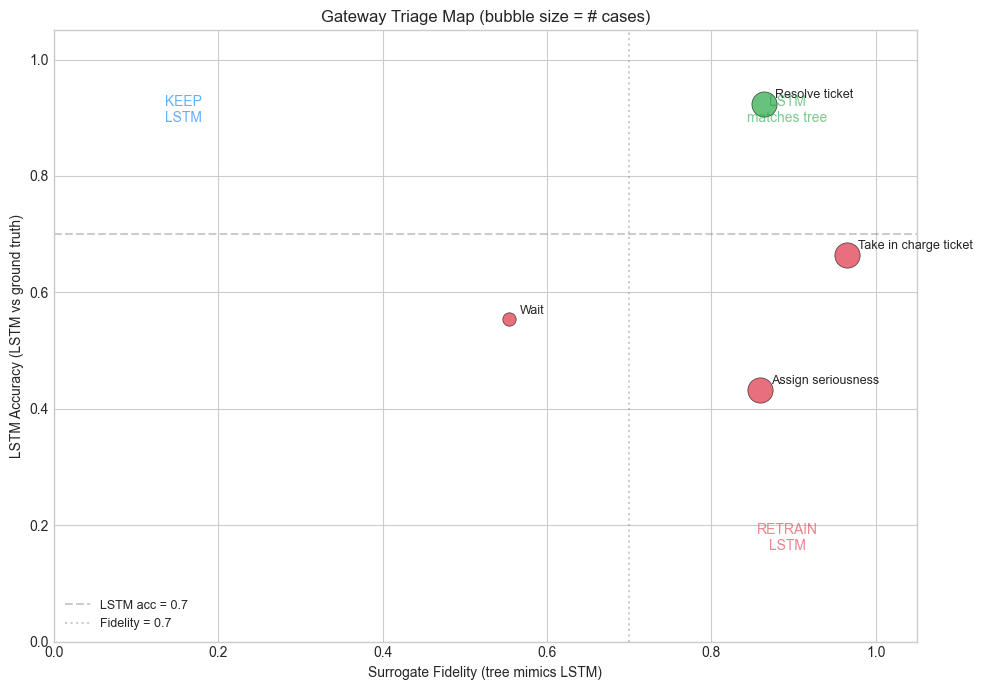

In [ ]:
# Visualization: Triage scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

colors_map = {
    'LSTM_MATCHES_TREE': '#28a745',
    'RETRAIN_LSTM': '#dc3545',
    'KEEP_LSTM': '#007bff',
    'INVESTIGATE': '#ffc107',
}

for _, row in master_df.iterrows():
    color = colors_map.get(row['Action'], 'gray')
    ax.scatter(row['Fidelity'], row['LSTM_Acc'], s=row['Cases'] / 3,
               c=color, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.annotate(row['Gateway'], (row['Fidelity'], row['LSTM_Acc']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

# Decision boundaries
ax.axhline(y=LSTM_ACC_HIGH, color='gray', linestyle='--', alpha=0.4, label=f'LSTM acc = {LSTM_ACC_HIGH}')
ax.axvline(x=FIDELITY_THRESH, color='gray', linestyle=':', alpha=0.4, label=f'Fidelity = {FIDELITY_THRESH}')

# Quadrant labels
ax.text(0.85, 0.85, 'LSTM\nmatches tree', transform=ax.transAxes, ha='center', fontsize=10, color='#28a745', alpha=0.6)
ax.text(0.85, 0.15, 'RETRAIN\nLSTM', transform=ax.transAxes, ha='center', fontsize=10, color='#dc3545', alpha=0.6)
ax.text(0.15, 0.85, 'KEEP\nLSTM', transform=ax.transAxes, ha='center', fontsize=10, color='#007bff', alpha=0.6)

ax.set_xlabel('Surrogate Fidelity (tree mimics LSTM)')
ax.set_ylabel('LSTM Accuracy (LSTM vs ground truth)')
ax.set_title('Gateway Triage Map (bubble size = # cases)')
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Summary & Recommendations

In [ ]:
print("=" * 100)
print("GATEWAY TRIAGE SUMMARY")
print("=" * 100)

for _, row in master_df.iterrows():
    gw = row['Gateway']
    print(f"\n{'─' * 80}")
    print(f"  {gw} ({int(row['Cases'])} cases)")
    print(f"  LSTM Accuracy: {row['LSTM_Acc']:.3f} | Fidelity: {row['Fidelity']:.3f} | GT Tree: {row['GT_Acc']:.3f}")
    print(f"  ACTION: {row['Action']}")
    print(f"  Explanation trust: Spearman r={row['IG_Trust']:.3f} — {row['Trustworthy']}")

    cat = row['Action']
    if cat == 'LSTM_MATCHES_TREE':
        print(f"  -> Gateway is well-understood. The LSTM and a simple decision tree agree.")
        print(f"     The tree can serve as a faithful, interpretable explanation of this gateway.")
    elif cat == 'RETRAIN_LSTM':
        print(f"  -> The surrogate captures what the LSTM does, but the LSTM is wrong.")
        print(f"     The tree reveals the failure pattern — use for targeted retraining.")
        if row['Top_Spurious_Feature'] != '-':
            print(f"     Suspect spurious feature: {row['Top_Spurious_Feature']} "
                  f"(+{row['Spurious_Delta']:.4f} attribution when wrong)")
        if row['Retrain_Candidates'] > 0:
            print(f"     {int(row['Retrain_Candidates'])} candidate prefixes for targeted retraining.")
    elif cat == 'KEEP_LSTM':
        print(f"  -> The LSTM outperforms the tree — it has learned something a tree can't express.")
        print(f"     Keep the LSTM; the tree explanation may be incomplete.")
    else:
        print(f"  -> Needs manual investigation.")

print(f"\n{'=' * 100}")
print(f"Total gateways: {len(master_df)}")
for cat in ['LSTM_MATCHES_TREE', 'RETRAIN_LSTM', 'KEEP_LSTM', 'INVESTIGATE']:
    n = (master_df['Action'] == cat).sum()
    if n > 0:
        print(f"  {cat}: {n}")

GATEWAY TRIAGE SUMMARY

────────────────────────────────────────────────────────────────────────────────
  Assign seriousness (995 cases)
  LSTM Accuracy: 0.432 | Fidelity: 0.859 | GT Tree: 0.789
  ACTION: RETRAIN_LSTM
  Explanation trust: Spearman r=0.476 — Yes
  -> The surrogate captures what the LSTM does, but the LSTM is wrong.
     The tree reveals the failure pattern — use for targeted retraining.
     Suspect spurious feature: event_elapsed_time (+0.0082 attribution when wrong)
     112 candidate prefixes for targeted retraining.

────────────────────────────────────────────────────────────────────────────────
  Take in charge ticket (996 cases)
  LSTM Accuracy: 0.665 | Fidelity: 0.965 | GT Tree: 0.665
  ACTION: RETRAIN_LSTM
  Explanation trust: Spearman r=0.257 — No
  -> The surrogate captures what the LSTM does, but the LSTM is wrong.
     The tree reveals the failure pattern — use for targeted retraining.
     Suspect spurious feature: seconds_in_day (+0.0098 attribution when

In [ ]:
# Save all results
import pickle
output_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'results' / 'helpdesk'
output_dir.mkdir(parents=True, exist_ok=True)

with open(output_dir / 'gateway_triage.pkl', 'wb') as f:
    pickle.dump({
        'master_df': master_df,
        'triage_df': triage_df,
        'trust_df': trust_df,
        'error_diagnostics': {gw: {k: v for k, v in ed.items() if k != 'rel_diff'}
                              for gw, ed in error_diagnostics.items()},
        'retraining_candidates': {gw: {'n_disagree': rc['n_disagree'],
                                        'n_total': rc['n_total'],
                                        'n_disagree_and_wrong': rc['n_disagree_and_wrong']}
                                  for gw, rc in retraining_candidates.items()},
    }, f)
print(f'Results saved to {output_dir / "gateway_triage.pkl"}')

Results saved to /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/results/helpdesk/gateway_triage.pkl
